# ML Model for Car Mileage Estimation

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
import warnings
warnings.filterwarnings('ignore')

print("All required libraries imported successfully!")

All required libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load dataset
try:
    df = pd.read_csv('auto-mpg.csv')
    print("Dataset loaded from local 'auto-mpg.csv'.")
except Exception:
    df = sns.load_dataset('mpg')
    print("Dataset loaded via seaborn repository.")

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset loaded from local 'auto-mpg.csv'.
Dataset Dimensions: 398 rows, 9 columns



,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Summary statistics for numerical features
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


## 3. Data Cleaning and Preprocessing

In [4]:
# Check column types and missing values
print("Information about dataset:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

Information about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [5]:
# Impute missing values in 'horsepower' with the median
median_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median_hp)

print(f"Missing horsepower values successfully imputed with median: {median_hp}")
print("Remaining null values in dataset:", df.isnull().sum().sum())

Missing horsepower values successfully imputed with median: 93.5
Remaining null values in dataset: 0


In [6]:
# Drop 'name' (high-cardinality identifier text)
df_clean = df.drop(columns=['name'])

# One-Hot Encode categorical variable 'origin'
df_clean = pd.get_dummies(df_clean, columns=['origin'], drop_first=True, dtype=int)

print("Preprocessed DataFrame Preview:")
df_clean.head()

Preprocessed DataFrame Preview:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


## 4. Exploratory Data Analysis (EDA)

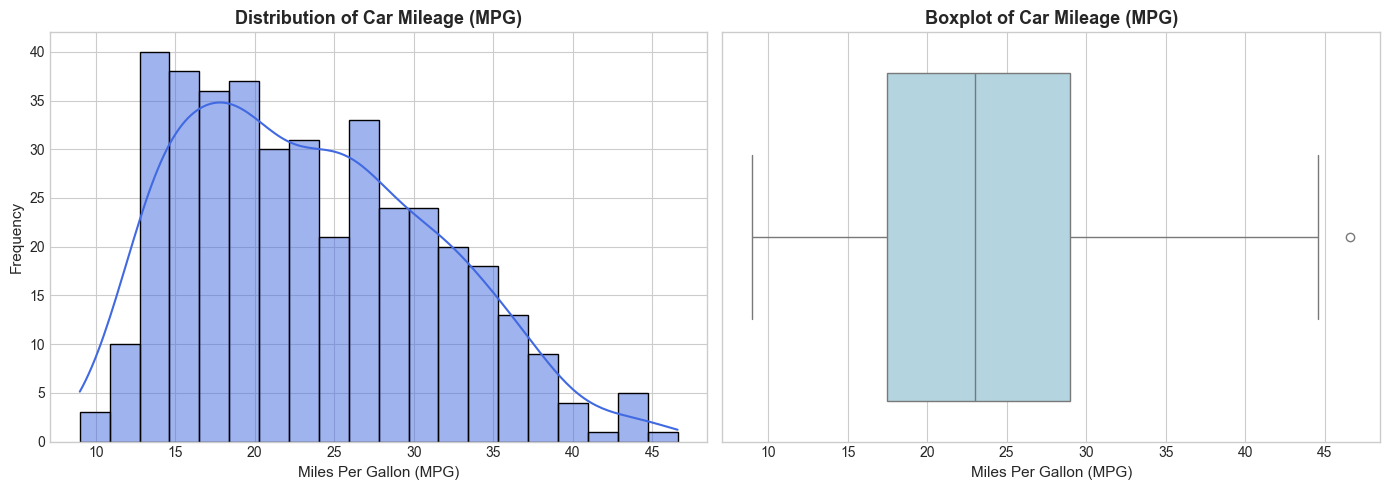

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of MPG
sns.histplot(df_clean['mpg'], kde=True, color='royalblue', bins=20, ax=axes[0])
axes[0].set_title('Distribution of Car Mileage (MPG)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Miles Per Gallon (MPG)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# Boxplot of MPG
sns.boxplot(x=df_clean['mpg'], color='lightblue', ax=axes[1])
axes[1].set_title('Boxplot of Car Mileage (MPG)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Miles Per Gallon (MPG)', fontsize=11)

plt.tight_layout()
plt.show()

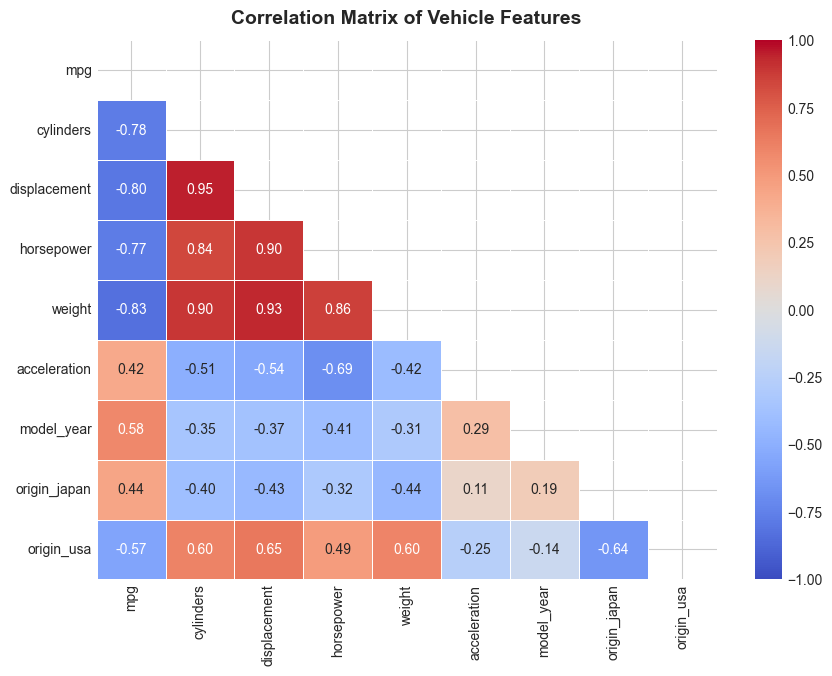

In [8]:
plt.figure(figsize=(10, 7))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Vehicle Features', fontsize=14, fontweight='bold', pad=12)
plt.show()

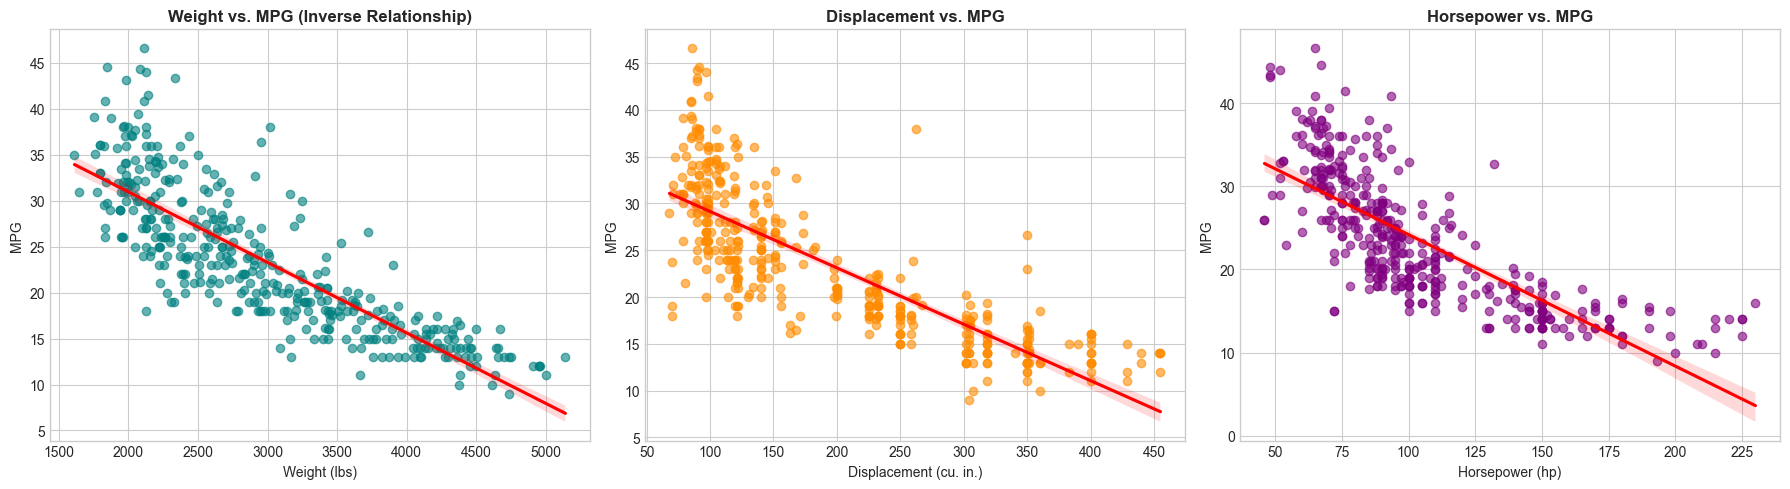

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Weight vs MPG
sns.regplot(data=df, x='weight', y='mpg', ax=axes[0], scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Weight vs. MPG (Inverse Relationship)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weight (lbs)')
axes[0].set_ylabel('MPG')

# Displacement vs MPG
sns.regplot(data=df, x='displacement', y='mpg', ax=axes[1], scatter_kws={'alpha':0.6, 'color':'darkorange'}, line_kws={'color':'red'})
axes[1].set_title('Displacement vs. MPG', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Displacement (cu. in.)')
axes[1].set_ylabel('MPG')

# Horsepower vs MPG
sns.regplot(data=df, x='horsepower', y='mpg', ax=axes[2], scatter_kws={'alpha':0.6, 'color':'purple'}, line_kws={'color':'red'})
axes[2].set_title('Horsepower vs. MPG', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Horsepower (hp)')
axes[2].set_ylabel('MPG')

plt.tight_layout()
plt.show()

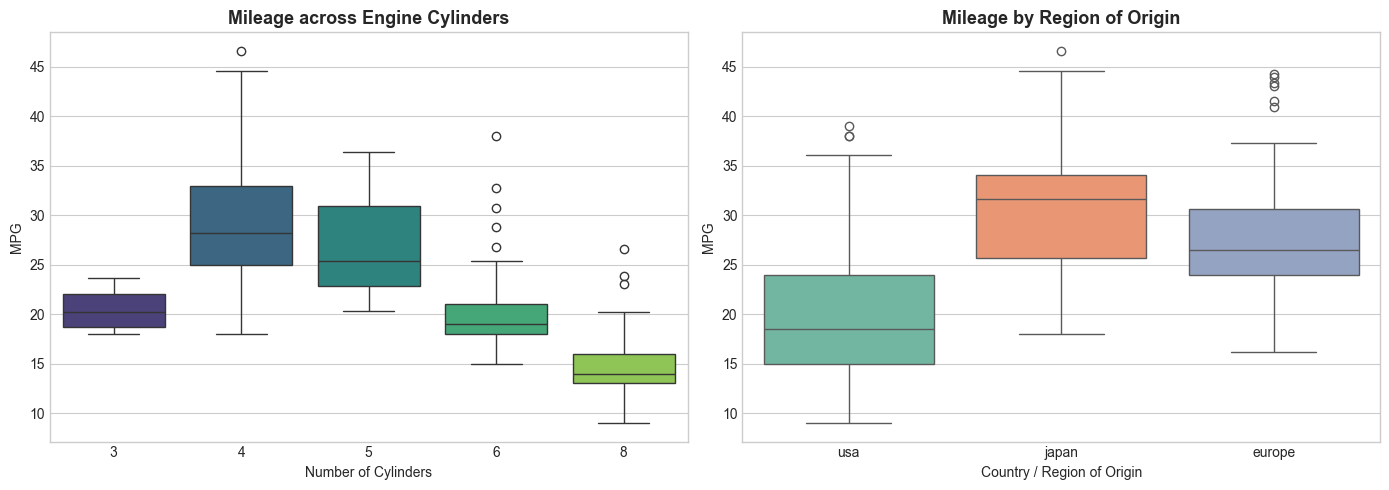

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cylinders vs MPG
sns.boxplot(data=df, x='cylinders', y='mpg', palette='viridis', ax=axes[0])
axes[0].set_title('Mileage across Engine Cylinders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cylinders')
axes[0].set_ylabel('MPG')

# Origin vs MPG
sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', ax=axes[1])
axes[1].set_title('Mileage by Region of Origin', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Country / Region of Origin')
axes[1].set_ylabel('MPG')

plt.tight_layout()
plt.show()

## 5. Feature Engineering and Train-Test Split

In [11]:
# Separate independent features (X) and target variable (y)
X = df_clean.drop(columns=['mpg'])
y = df_clean['mpg']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print("Features:", list(X.columns))

Training set: 318 samples
Testing set:  80 samples
Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


In [12]:
# Feature Standardization
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("StandardScaler successfully fit on training data and transformed test data.")

StandardScaler successfully fit on training data and transformed test data.


## 6. Model Training (Linear Regression, Ridge, Lasso, Random Forest)

In [13]:
# Model 1: Simple Linear Regression (Weight -> MPG)
X_train_slr = X_train[['weight']]
X_test_slr = X_test[['weight']]

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train)
y_pred_slr = slr_model.predict(X_test_slr)

print(f"Simple Linear Regression (Weight -> MPG):")
print(f"  Coefficient (Slope):     {slr_model.coef_[0]:.4f}")
print(f"  Intercept:               {slr_model.intercept_:.4f}")
print(f"  Test R² Score:           {r2_score(y_test, y_pred_slr):.4f}")

Simple Linear Regression (Weight -> MPG):
  Coefficient (Slope):     -0.0078
  Intercept:               46.7821
  Test R² Score:           0.7230


In [14]:
# Model 2: Multiple Linear Regression (All features)
mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train)
y_pred_mlr = mlr_model.predict(X_test_scaled)

print("Multiple Linear Regression Trained.")
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Scaled)': mlr_model.coef_
}).sort_values(by='Coefficient (Scaled)', ascending=False)
coeff_df

Multiple Linear Regression Trained.


,Feature,Coefficient (Scaled)
5,model_year,2.971431
1,displacement,2.033373
4,acceleration,0.187514
6,origin_japan,-0.111843
0,cylinders,-0.278695
2,horsepower,-0.539182
7,origin_usa,-1.433003
3,weight,-5.914735


In [15]:
# Model 3: Ridge Regression (L2)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Model 4: Lasso Regression (L1)
lasso_model = Lasso(alpha=0.05)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Ridge and Lasso Regression Models successfully trained.")

Ridge and Lasso Regression Models successfully trained.


In [16]:
# Model 5: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor successfully trained.")

Random Forest Regressor successfully trained.


## 7. Model Evaluation and Comparison

In [17]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': name,
        'MAE': round(mae, 3),
        'MSE': round(mse, 3),
        'RMSE': round(rmse, 3),
        'R² Score': round(r2, 4)
    }

results = [
    evaluate_model('Simple Linear Regression (Weight)', y_test, y_pred_slr),
    evaluate_model('Multiple Linear Regression', y_test, y_pred_mlr),
    evaluate_model('Ridge Regression (L2)', y_test, y_pred_ridge),
    evaluate_model('Lasso Regression (L1)', y_test, y_pred_lasso),
    evaluate_model('Random Forest Regressor', y_test, y_pred_rf),
]

results_df = pd.DataFrame(results)
print("=== Model Performance Comparison on Test Set ===")
results_df

=== Model Performance Comparison on Test Set ===


,Model,MAE,MSE,RMSE,R² Score
0,Simple Linear Regression (Weight),3.118,14.895,3.859,0.7230
1,Multiple Linear Regression,2.288,8.339,2.888,0.8449
2,Ridge Regression (L2),2.283,8.338,2.888,0.8449
3,Lasso Regression (L1),2.285,8.472,2.911,0.8424
4,Random Forest Regressor,1.601,4.592,2.143,0.9146


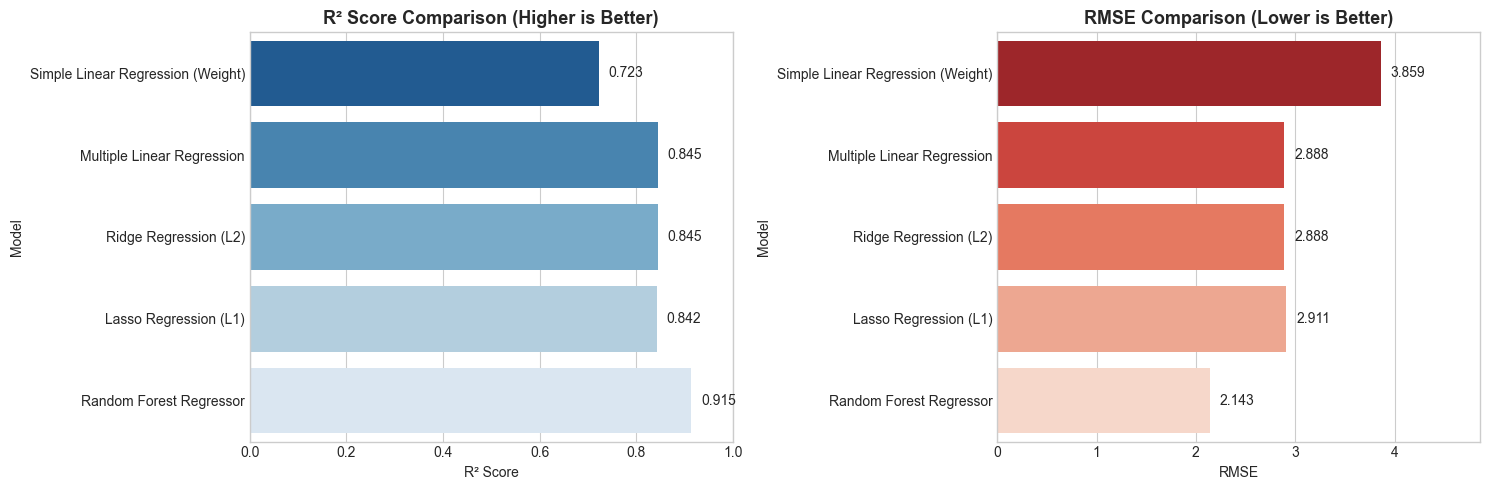

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R2 Score comparison
sns.barplot(data=results_df, x='R² Score', y='Model', palette='Blues_r', ax=axes[0])
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.3f}", 
                     (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10)

# RMSE comparison
sns.barplot(data=results_df, x='RMSE', y='Model', palette='Reds_r', ax=axes[1])
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, max(results_df['RMSE']) + 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.3f}", 
                     (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Diagnostic Visualizations (Residuals & Actual vs Predicted)

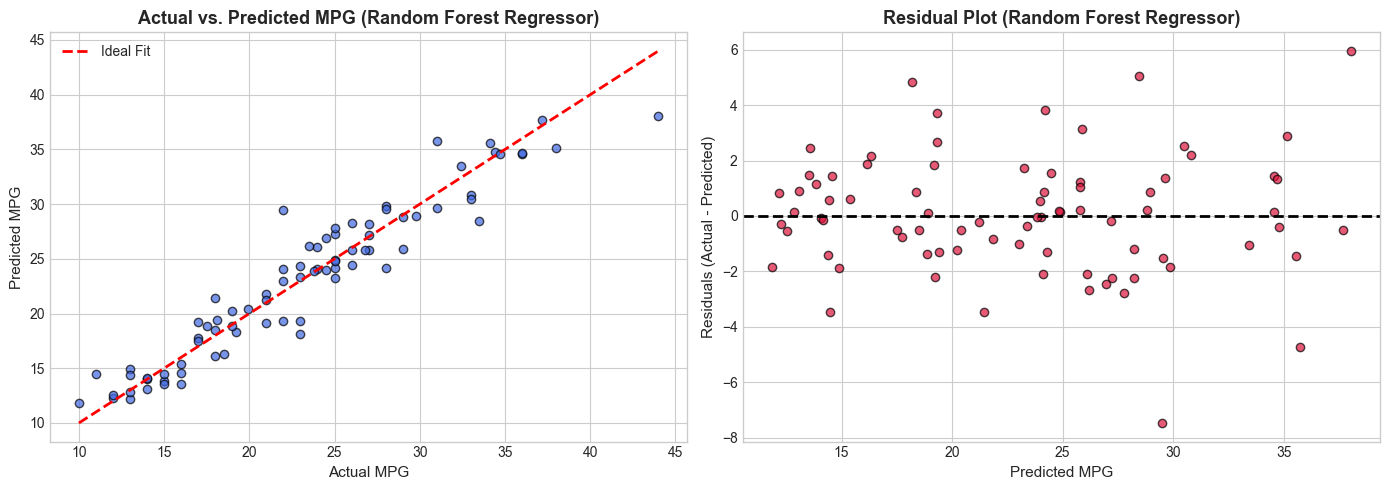

In [19]:
best_model_name = "Random Forest Regressor"
best_predictions = y_pred_rf
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_predictions, color='royalblue', alpha=0.7, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
axes[0].set_title(f'Actual vs. Predicted MPG ({best_model_name})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual MPG', fontsize=11)
axes[0].set_ylabel('Predicted MPG', fontsize=11)
axes[0].legend()

# Residual Plot
axes[1].scatter(best_predictions, residuals, color='crimson', alpha=0.7, edgecolors='k')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title(f'Residual Plot ({best_model_name})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted MPG', fontsize=11)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)

plt.tight_layout()
plt.show()

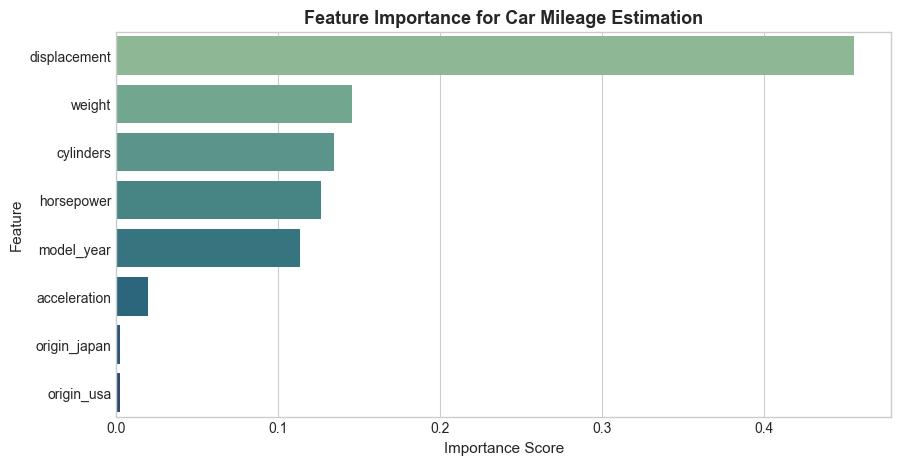

In [20]:
# Feature Importance from Random Forest Regressor
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')
plt.title('Feature Importance for Car Mileage Estimation', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.show()

## 9. Sample Prediction

In [21]:
def predict_car_mileage(cylinders, displacement, horsepower, weight, acceleration, model_year, origin):
    """
    Estimates fuel economy (MPG) using the trained Random Forest model.
    origin: 'usa', 'japan', or 'europe'
    """
    input_data = {
        'cylinders': cylinders,
        'displacement': displacement,
        'horsepower': horsepower,
        'weight': weight,
        'acceleration': acceleration,
        'model_year': model_year,
        'origin_japan': 1 if origin.lower() == 'japan' else 0,
        'origin_usa': 1 if origin.lower() == 'usa' else 0
    }
    input_df = pd.DataFrame([input_data])
    predicted_mpg = rf_model.predict(input_df)[0]
    return predicted_mpg

# Sample Test Case: Compact 4-cylinder Japanese car
sample_car = {
    'cylinders': 4,
    'displacement': 120.0,
    'horsepower': 85.0,
    'weight': 2200,
    'acceleration': 15.5,
    'model_year': 80,
    'origin': 'japan'
}

estimated_mpg = predict_car_mileage(**sample_car)
print("=== Sample Car Mileage Prediction ===")
for k, v in sample_car.items():
    print(f"  {k:15s}: {v}")
print(f"\n=> Estimated Mileage: {estimated_mpg:.2f} MPG (~{estimated_mpg * 0.425144:.2f} km/l)")

=== Sample Car Mileage Prediction ===
  cylinders      : 4
  displacement   : 120.0
  horsepower     : 85.0
  weight         : 2200
  acceleration   : 15.5
  model_year     : 80
  origin         : japan

=> Estimated Mileage: 33.98 MPG (~14.45 km/l)


## 10. Conclusion